Reading: Amazon_stock_data.csv

--- First 5 Rows ---


,Date,Close,High,Low,Open,Volume
0,1997-05-15,0.097917,0.125000,0.096354,0.121875,1443120000
1,1997-05-16,0.086458,0.098958,0.085417,0.098438,294000000
2,1997-05-19,0.085417,0.088542,0.081250,0.088021,122136000
3,1997-05-20,0.081771,0.087500,0.081771,0.086458,109344000
4,1997-05-21,0.071354,0.082292,0.068750,0.081771,377064000



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7186 entries, 0 to 7185
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7186 non-null   datetime64[us]
 1   Close   7186 non-null   float64       
 2   High    7186 non-null   float64       
 3   Low     7186 non-null   float64       
 4   Open    7186 non-null   float64       
 5   Volume  7186 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 337.0 KB
None

--- Statistical Summary ---


,Date,Close,High,Low,Open,Volume
count,7186,7186.000000,7186.000000,7186.000000,7186.000000,7.186000e+03
mean,2011-08-25 05:45:40.328416,45.506502,46.046493,44.940698,45.518874,1.335846e+08
min,1997-05-15 00:00:00,0.069792,0.072396,0.065625,0.070313,9.744000e+06
25%,2004-07-08 06:00:00,2.146906,2.188500,2.111750,2.144062,6.101950e+07
50%,2011-08-23 12:00:00,9.507750,9.652750,9.341500,9.491750,9.853000e+07
75%,2018-10-11 18:00:00,84.196877,85.249874,83.077873,84.120127,1.533565e+08
max,2025-12-05 00:00:00,254.000000,258.600006,252.899994,255.360001,2.086584e+09
std,NaN,64.109275,64.848315,63.350910,64.142922,1.364857e+08



--- Missing Values ---
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


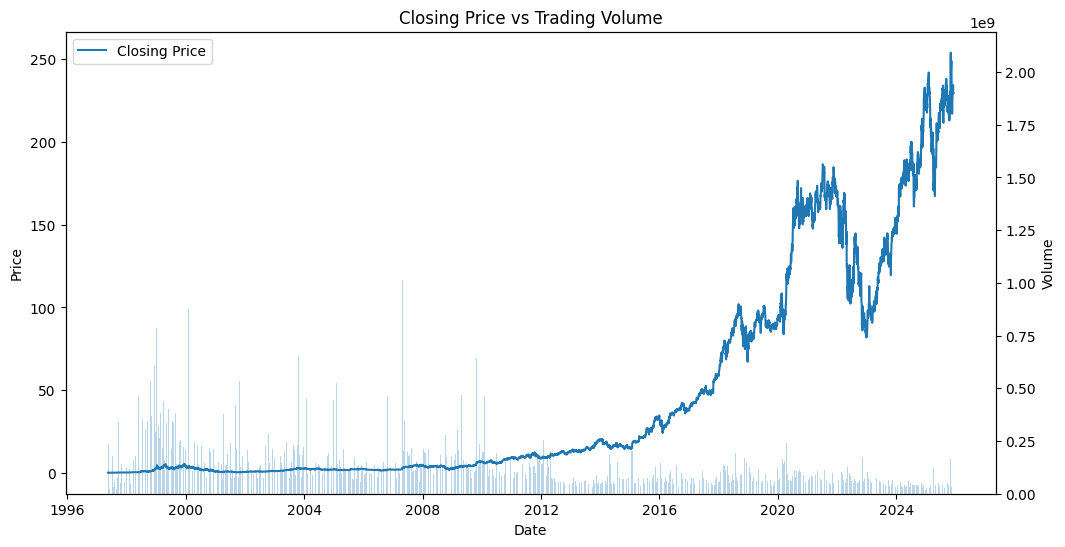

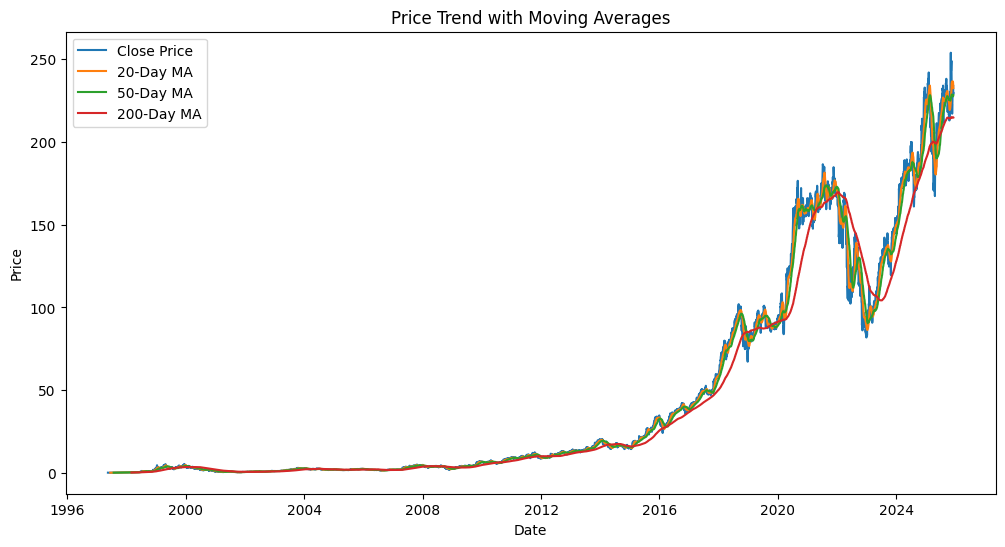

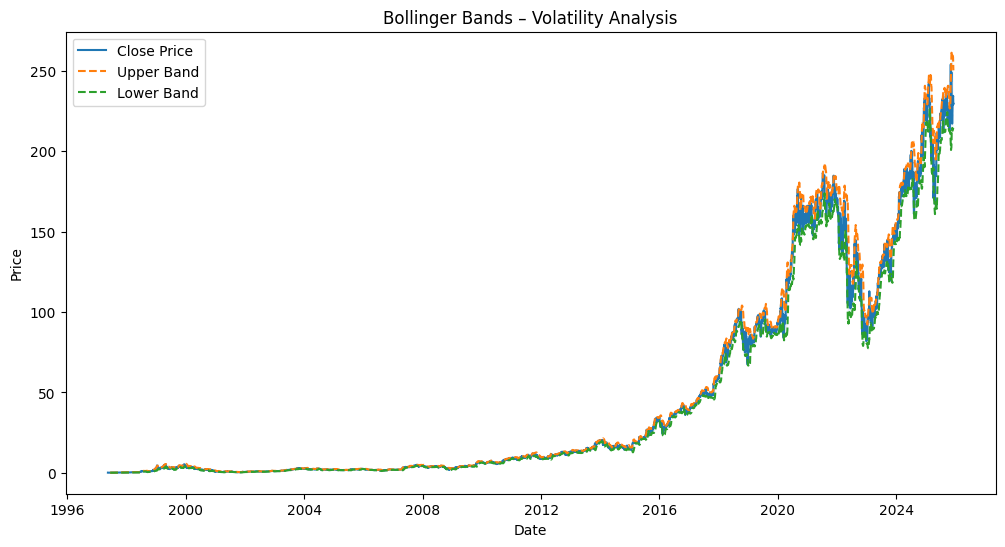

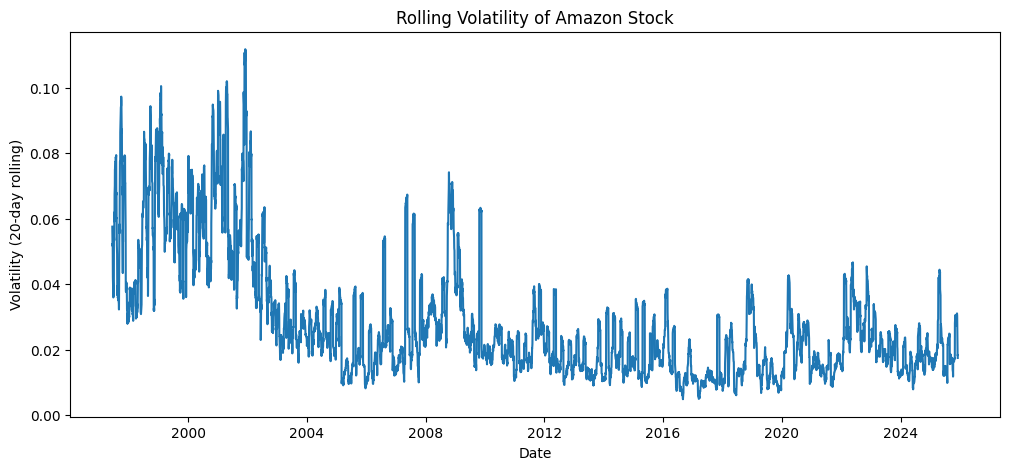

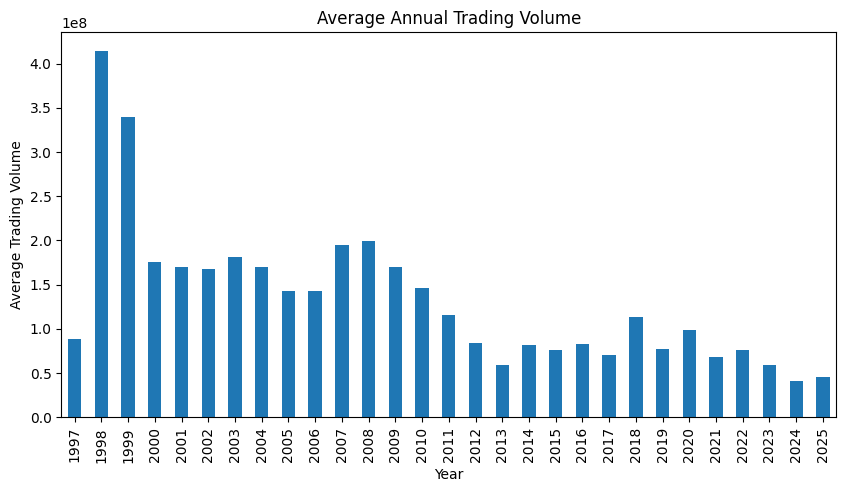

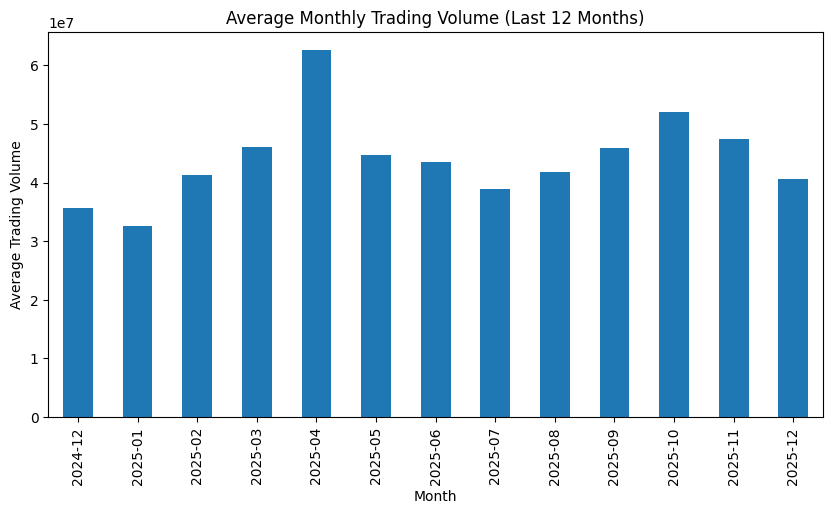

--- Data Split Complete ---
Training Data: 5588 days
Testing Data:  1398 days

--- Model Performance ---
Mean Absolute Error (MAE): $2.47
R2 Score (Accuracy):       0.9917


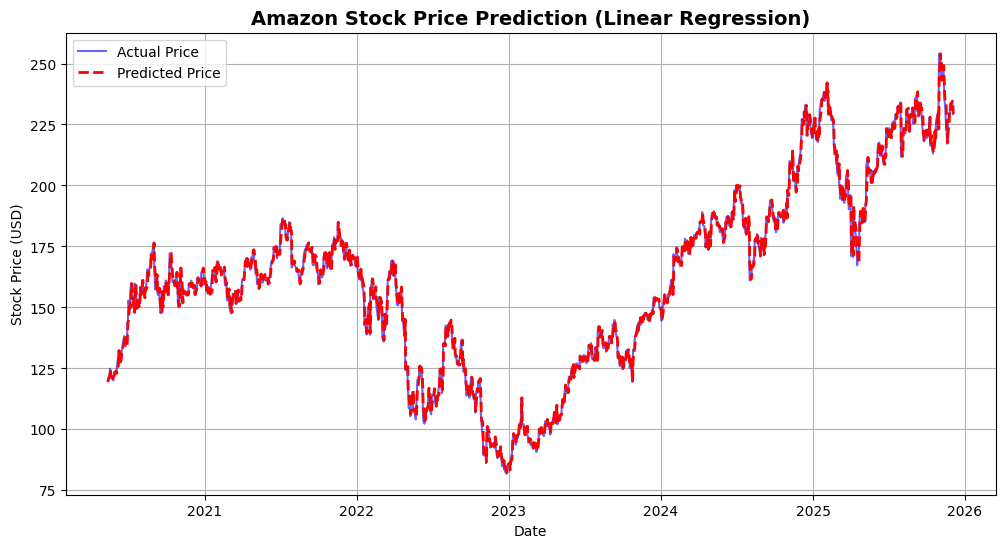

--- FORECAST ---
Latest Date in Data: 2025-12-04
Closing Price on that day: $229.11
------------------------------------------------
PREDICTED Price for Next Trading Day: $229.40

--- 'WHAT-IF' SCENARIO ---
If today's Close is $250.00, the model predicts tomorrow will be: $250.17


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import zipfile
import os

zip_name = 'Amazon_Stock_Price_History.zip'

if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        
        if csv_files:
            target_csv = csv_files[0]
            print(f"Reading: {target_csv}")
            
            with z.open(target_csv) as f:
                df = pd.read_csv(f)
        else:
            print("No CSV file found inside the Zip.")
            df = None
else:
    print(f"File '{zip_name}' not found.")
    df = None

if df is not None:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date')
    df = df.reset_index(drop=True)

    print("\n--- First 5 Rows ---")
    display(df.head())

    print("\n--- Data Info ---")
    print(df.info())

    print("\n--- Statistical Summary ---")
    display(df.describe())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())


fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Close'], label='Closing Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Volume'], alpha=0.3)
ax2.set_ylabel('Volume')

plt.title('Closing Price vs Trading Volume')
plt.show()

df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA20'], label='20-Day MA')
plt.plot(df['Date'], df['MA50'], label='50-Day MA')
plt.plot(df['Date'], df['MA200'], label='200-Day MA')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Trend with Moving Averages')
plt.legend()
plt.show()

df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Std'] = df['Close'].rolling(window=20).std()

df['BB_Upper'] = df['BB_Middle'] + 2 * df['BB_Std']
df['BB_Lower'] = df['BB_Middle'] - 2 * df['BB_Std']

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['BB_Upper'], linestyle='--', label='Upper Band')
plt.plot(df['Date'], df['BB_Lower'], linestyle='--', label='Lower Band')

plt.fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'], alpha=0.1)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bollinger Bands – Volatility Analysis')
plt.legend()
plt.show()


df['Daily_Return'] = df['Close'].pct_change()

df['Rolling_Volatility'] = df['Daily_Return'].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Rolling_Volatility'])

plt.xlabel('Date')
plt.ylabel('Volatility (20-day rolling)')
plt.title('Rolling Volatility of Amazon Stock')
plt.show()

df['Year'] = df['Date'].dt.year

yearly_volume = df.groupby('Year')['Volume'].mean()

plt.figure(figsize=(10,5))
yearly_volume.plot(kind='bar')

plt.xlabel('Year')
plt.ylabel('Average Trading Volume')
plt.title('Average Annual Trading Volume')
plt.show()

last_12_months = df[df['Date'] >= df['Date'].max() - pd.DateOffset(months=12)]

last_12_months = df[df['Date'] >= df['Date'].max() - pd.DateOffset(months=12)].copy()
last_12_months['Month'] = last_12_months['Date'].dt.to_period('M')

monthly_volume = last_12_months.groupby('Month')['Volume'].mean()

plt.figure(figsize=(10,5))
monthly_volume.plot(kind='bar')

plt.xlabel('Month')
plt.ylabel('Average Trading Volume')
plt.title('Average Monthly Trading Volume (Last 12 Months)')
plt.show()


df['Next_Close'] = df['Close'].shift(-1)

features = [
    'Close', 'Volume', 
    'MA20', 'MA50', 'MA200', 
    'BB_Upper', 'BB_Lower', 
    'Rolling_Volatility'
]

df_model = df.dropna().copy()

X = df_model[features]
y = df_model['Next_Close']

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("--- Data Split Complete ---")
print(f"Training Data: {len(X_train)} days")
print(f"Testing Data:  {len(X_test)} days")


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


predictions = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R2 Score (Accuracy):       {r2:.4f}")

plt.figure(figsize=(12, 6))

test_dates = df_model['Date'].iloc[split_index:]

plt.plot(test_dates, y_test, label='Actual Price', color='blue', alpha=0.6)
plt.plot(test_dates, predictions, label='Predicted Price', color='red', linestyle='--', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.title('Amazon Stock Price Prediction (Linear Regression)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# STEP 8: PREDICTION SYSTEM (FIXED)

def predict_future_price(current_data, model):
    # 1. Define the exact features the model expects
    features_needed = ['Close', 'Volume', 'MA20', 'MA50', 'MA200', 'BB_Upper', 'BB_Lower', 'Rolling_Volatility']
    
    # 2. Create a DataFrame with proper column names
    # This prevents the "X does not have valid feature names" warning
    input_data = pd.DataFrame([current_data[features_needed].values], columns=features_needed)
    
    # 3. Make Prediction
    predicted_price = model.predict(input_data)[0]
    
    return predicted_price

#TEST 1: Forecast using the latest real data
last_day_data = df_model.iloc[-1]
last_date = last_day_data['Date']

future_prediction = predict_future_price(last_day_data, lr_model)

print(f"--- FORECAST ---")
print(f"Latest Date in Data: {last_date.date()}")
print(f"Closing Price on that day: ${last_day_data['Close']:.2f}")
print(f"------------------------------------------------")
print(f"PREDICTED Price for Next Trading Day: ${future_prediction:.2f}")


#TEST 2: Manual 'What-If' Scenario
print("\n--- 'WHAT-IF' SCENARIO ---")
# Example: What if price hits $250 with huge volume?
manual_input = pd.Series({
    'Close': 250.00, 
    'Volume': 50000000,
    'MA20': 245.00, 'MA50': 240.00, 'MA200': 220.00,
    'BB_Upper': 255.00, 'BB_Lower': 235.00,
    'Rolling_Volatility': 0.02
})

hypothetical_pred = predict_future_price(manual_input, lr_model)
print(f"If today's Close is $250.00, the model predicts tomorrow will be: ${hypothetical_pred:.2f}")